In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")


In [4]:
%pip install scikit-learn


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------- -------------------------- 2.9/8.3 MB 22.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 26.9 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 28 monthly files in: c:\Users\alexa\Downloads\IDX Summer DS\raw data
(611540, 85)
              BuyerAgentAOR              ListAgentAOR          Flooring  \
0               Mlslistings               Mlslistings  Carpet,Tile,Wood   
1                HighDesert                HighDesert               NaN   
2              OrangeCounty              OrangeCounty               NaN   
3             InlandValleys             InlandValleys               NaN   
4  SouthwestRiversideCounty  SouthwestRiversideCounty               NaN   

  ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0   True          NaN        NaN         False           499000.0   551985747   
1    NaN          NaN        NaN           NaN                0.0   535486633   
2   True          NaN        NaN           NaN            75000.0   529986282   
3   True          NaN        NaN           NaN           199000.0   529618166   
4   True          NaN        NaN           NaN          

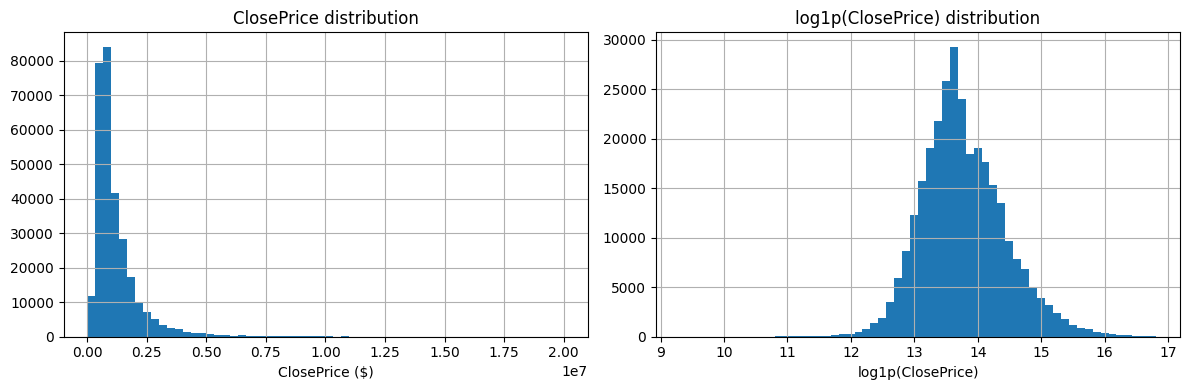

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet
count  301211.000000  301211.000000          301211.000000       3.012110e+05
mean     2027.322168       3.478479               2.607909       2.161255e+04
std       996.018163       0.949925               1.098924       1.478936e+05
min         0.000000       0.000000               0.000000       0.000000e+00
25%      1376.000000       3.000000               2.000000       5.663000e+03
50%      1803.000000       3.000000               2.000000       7.237000e+03
75%      2420.000000       4.000000               3.000000       1.028900e+04
max     17153.000000      14.000000              14.000000       1.251740e+07


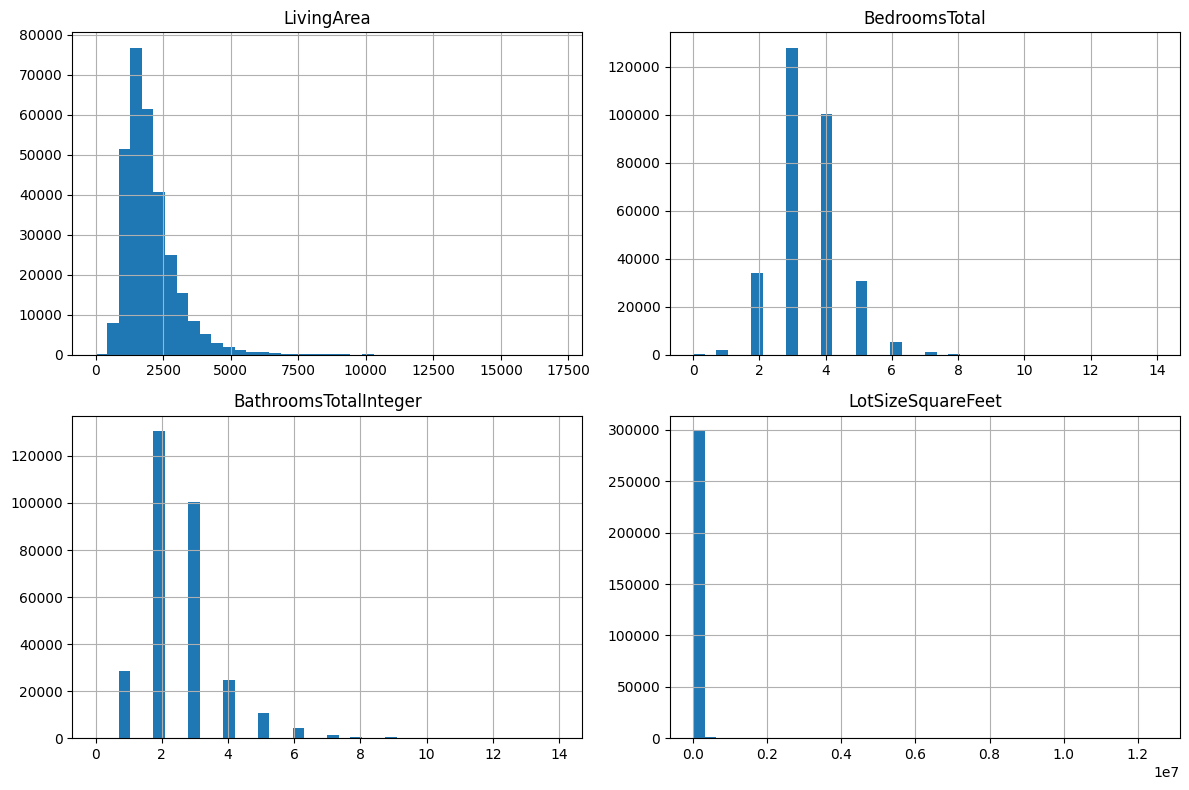

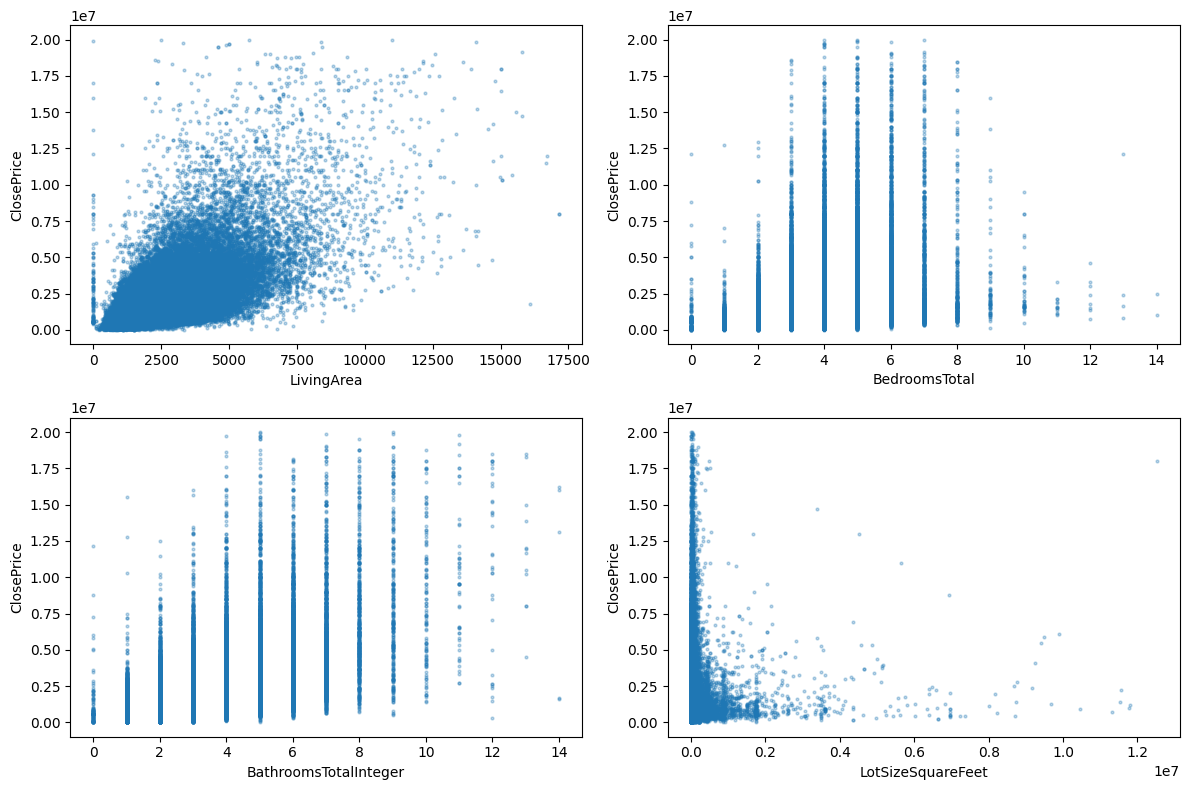

                       LivingArea  BedroomsTotal  BathroomsTotalInteger  \
LivingArea               1.000000       0.663352               0.846969   
BedroomsTotal            0.663352       1.000000               0.655526   
BathroomsTotalInteger    0.846969       0.655526               1.000000   
LotSizeSquareFeet        0.081561       0.019128               0.050175   
ClosePrice               0.625076       0.345075               0.576455   

                       LotSizeSquareFeet  ClosePrice  
LivingArea                      0.081561    0.625076  
BedroomsTotal                   0.019128    0.345075  
BathroomsTotalInteger           0.050175    0.576455  
LotSizeSquareFeet               1.000000    0.035960  
ClosePrice                      0.035960    1.000000  
SourceMonth
2024-01     8173
2024-02     9359
2024-03    11413
2024-04    12531
2024-05    13581
2024-06    12307
2024-07    13126
2024-08    12187
2024-09    10718
2024-10    12130
2024-11    10505
2024-12    10413
202

In [2]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 5)

# "raw data" is a sibling folder to "py files" (both live inside "IDX Summer DS")
DATA_DIR = os.path.join("..", "raw data")

# Minimum number of most-recent months to load (per Week 1 task doc: at least 6)
MIN_MONTHS = 6

# --- 1. Load the monthly files ---------------------------------------------
def month_from_filename(path):
    """Extract the YYYYMM tag from a CRMLSSoldYYYYMM.csv filename."""
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
print(f"Found {len(files)} monthly files in: {os.path.abspath(DATA_DIR)}")
assert len(files) >= MIN_MONTHS, f"Need at least {MIN_MONTHS} months of data, found {len(files)}"

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)
print(raw.shape)
print(raw.head())

# --- 2. Restrict to Residential / Single Family Residence -------------------
df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows before filter: {len(raw):,}")
print(f"Rows after filter:  {len(df):,}")
print(df[["PropertyType", "PropertySubType"]].value_counts().head())
# Drop obvious data-entry errors / outliers before analysis
df = df[
    (df["ClosePrice"] > 10000) &              # exclude $0 or near-$0 placeholder rows
    (df["ClosePrice"] < 20_000_000) &         # exclude implausible high-end errors
    (df["BedroomsTotal"] < 15) &
    (df["BathroomsTotalInteger"] < 15) &      # caps unrealistic values like 175 bathrooms
    (df["LivingArea"] < 20000) &
    (df["LotSizeSquareFeet"] < 13_068_000)    # ~300 acres
]
print(f"Rows after outlier filtering: {len(df):,}")

# --- 3. Quick data overview ---------------------------------------------
df.info()

missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].to_frame("pct_missing"))

# --- 4. Target variable — ClosePrice ----------------------------------------
print(df["ClosePrice"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["ClosePrice"].hist(bins=60, ax=axes[0])
axes[0].set_title("ClosePrice distribution")
axes[0].set_xlabel("ClosePrice ($)")

np.log1p(df["ClosePrice"]).hist(bins=60, ax=axes[1])
axes[1].set_title("log1p(ClosePrice) distribution")
axes[1].set_xlabel("log1p(ClosePrice)")
plt.tight_layout()
plt.savefig("closeprice_distribution.png")
plt.show()

# --- 5. Feature distributions — LivingArea, Bedrooms, Bathrooms, LotSize ----
feature_cols = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
# NOTE: adjust these to the exact column names in Trestle Property MetaData.pdf if they differ
# (e.g. some feeds use "Bedrooms" / "Bathrooms" / "LotSize" directly).

available = [c for c in feature_cols if c in df.columns]
missing_cols = [c for c in feature_cols if c not in df.columns]
if missing_cols:
    print("Not found in this feed, check Trestle Property MetaData.pdf for the correct name:", missing_cols)

print(df[available].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), available):
    df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("feature_distributions.png")
plt.show()

# --- 6. Relationship to ClosePrice ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), available):
    ax.scatter(df[col], df["ClosePrice"], s=4, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("ClosePrice")
plt.tight_layout()
plt.savefig("feature_vs_closeprice.png")
plt.show()

print(df[available + ["ClosePrice"]].corr())

# --- 7. Coverage by month ---------------------------------------------------
print(df["SourceMonth"].value_counts().sort_index())

In [ ]:
import glob
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 60)

DATA_DIR = os.path.join("..", "raw data")
OUTPUT_CSV = "cleaned_crmls_sold.csv"   

TARGET = "ClosePrice"
NUMERIC_FEATURES = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]

CATEGORICAL_FEATURES = ["City", "PropertySubType"]
DATE_COL = "CloseDate"   

def month_from_filename(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
assert files, f"No CRMLSSold*.csv files found in {os.path.abspath(DATA_DIR)}"

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)

df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(df.shape)

df = df[
    (df["ClosePrice"] > 10000) &
    (df["ClosePrice"] < 20_000_000) &
    (df["BedroomsTotal"] < 15) &
    (df["BathroomsTotalInteger"] < 15) &
    (df["LivingArea"] < 20000) &
    (df["LotSizeSquareFeet"] < 13_068_000)
]
print(f"Rows after outlier filtering: {len(df):,}")


df = df.dropna(subset=[TARGET])

missing_frac = df.isna().mean()
mostly_empty = missing_frac[missing_frac > 0.6].index.tolist()
print("Dropping mostly-empty columns:", mostly_empty)
df = df.drop(columns=mostly_empty)

for col in NUMERIC_FEATURES:
    if col not in df.columns:
        continue
    if df[col].isna().any():
        df[f"{col}_was_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())

for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("Remaining nulls in modeling columns:")
cols_to_check = [c for c in (NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]) if c in df.columns]
print(df[cols_to_check].isna().sum())

cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in df.columns]

for col in cat_cols_present:
    print(col, "unique values:", df[col].nunique())

df_encoded = pd.get_dummies(df, columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
print(df_encoded.shape)

numeric_cols_present = [c for c in NUMERIC_FEATURES if c in df_encoded.columns]
print("Numeric columns to scale:", numeric_cols_present)

def build_split(data: pd.DataFrame, x_months: int, month_col: str = "SourceMonth"):
    """Return (train_df, test_df) for a given training-window length X.

    test  = most recent month in `data`
    train = the x_months immediately preceding the test month
    """
    months_available = sorted(data[month_col].unique())
    test_month = months_available[-1]
    train_months = months_available[-(x_months + 1):-1]

    if len(train_months) < x_months:
        raise ValueError(
            f"Only {len(train_months)} prior months available, requested X={x_months}"
        )

    train_df = data[data[month_col].isin(train_months)].copy()
    test_df = data[data[month_col] == test_month].copy()
    return train_df, test_df, train_months, test_month

X = 3
train_df, test_df, train_months, test_month = build_split(df_encoded, X)

print("Train months:", train_months)
print("Test month:  ", test_month)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

months_available = sorted(df_encoded["SourceMonth"].unique())
max_x = len(months_available) - 1  # leave at least 1 month for test

summary = []
for x in range(1, max_x + 1):
    _, _, tm, test_m = build_split(df_encoded, x)
    summary.append({
        "X": x,
        "train_rows": len(df_encoded[df_encoded['SourceMonth'].isin(tm)]),
        "train_months": f"{tm[0]}..{tm[-1]}"
    })

print(pd.DataFrame(summary))

scaler = StandardScaler()
train_df[numeric_cols_present] = scaler.fit_transform(train_df[numeric_cols_present])
test_df[numeric_cols_present] = scaler.transform(test_df[numeric_cols_present])

train_df["split"] = "train"
test_df["split"] = "test"
final_df = pd.concat([train_df, test_df], ignore_index=True)
print(final_df.head())


final_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(final_df):,} rows to {OUTPUT_CSV}")
print(final_df['split'].value_counts())

(307172, 85)
Rows after outlier filtering: 301,211
Dropping mostly-empty columns: ['WaterfrontYN', 'BasementYN', 'CoListOfficeName', 'CoListAgentFirstName', 'CoListAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'ElementarySchool', 'BuilderName', 'SubdivisionName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict', 'OriginatingSystemName', 'OriginatingSystemSubName', 'BuyerAgencyCompensationType', 'BuyerAgencyCompensation', 'latfilled', 'lonfilled']
Remaining nulls in modeling columns:
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
LotSizeSquareFeet        0
City                     0
PropertySubType          0
ClosePrice               0
dtype: int64
City unique values: 1100
PropertySubType unique values: 1
(30121